In [1]:
import torch

import sys
sys.path.append("../")
from utils import Learner

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache() 
# pip install importlib-metadata warp-lang

dry_run = False
# dry_run=True
save = not dry_run
epochs = 5 if dry_run else 500
print_every = 1 if dry_run else 10

## NS_Heat

In [ ]:
from utils import MPData
data_name = 'NS_heat'
model_name= 'CPodONet'
out_channels= 5 if data_name == 'MHD' else 3
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import ChannelPodONet
from neuralop.utils import count_model_params
p = 512
model = ChannelPodONet(p=p, out_channels=out_channels).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 11,476,672 parameters.


In [22]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 11,476,672


In [23]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 2.73/0.10 | loss: 2.78e-01 | test: 6.87e-02 | norm: 0.12


epoch:10 | time: 2.76/0.10 | loss: 1.03e-02 | test: 1.02e-02 | norm: 0.04


epoch:20 | time: 2.80/0.10 | loss: 6.13e-03 | test: 5.93e-03 | norm: 0.04


epoch:30 | time: 2.79/0.10 | loss: 3.99e-03 | test: 4.10e-03 | norm: 0.03


epoch:40 | time: 2.79/0.10 | loss: 2.55e-03 | test: 2.73e-03 | norm: 0.02


...

epoch:470 | time: 2.79/0.10 | loss: 2.72e-04 | test: 3.35e-04 | norm: 0.00


epoch:480 | time: 2.79/0.10 | loss: 2.71e-04 | test: 3.32e-04 | norm: 0.00


epoch:490 | time: 2.79/0.10 | loss: 2.70e-04 | test: 3.34e-04 | norm: 0.00


epoch:499 | time: 2.79/0.10 | loss: 2.69e-04 | test: 3.29e-04 | norm: 0.00


Finish epoch:499 | train loss: 2.6868e-04 | test loss: 3.2944e-04
total train time : 1394.779
Channel Loss: var0: 1.4882e-04 var1: 1.2975e-04 var2: 5.0863e-05 



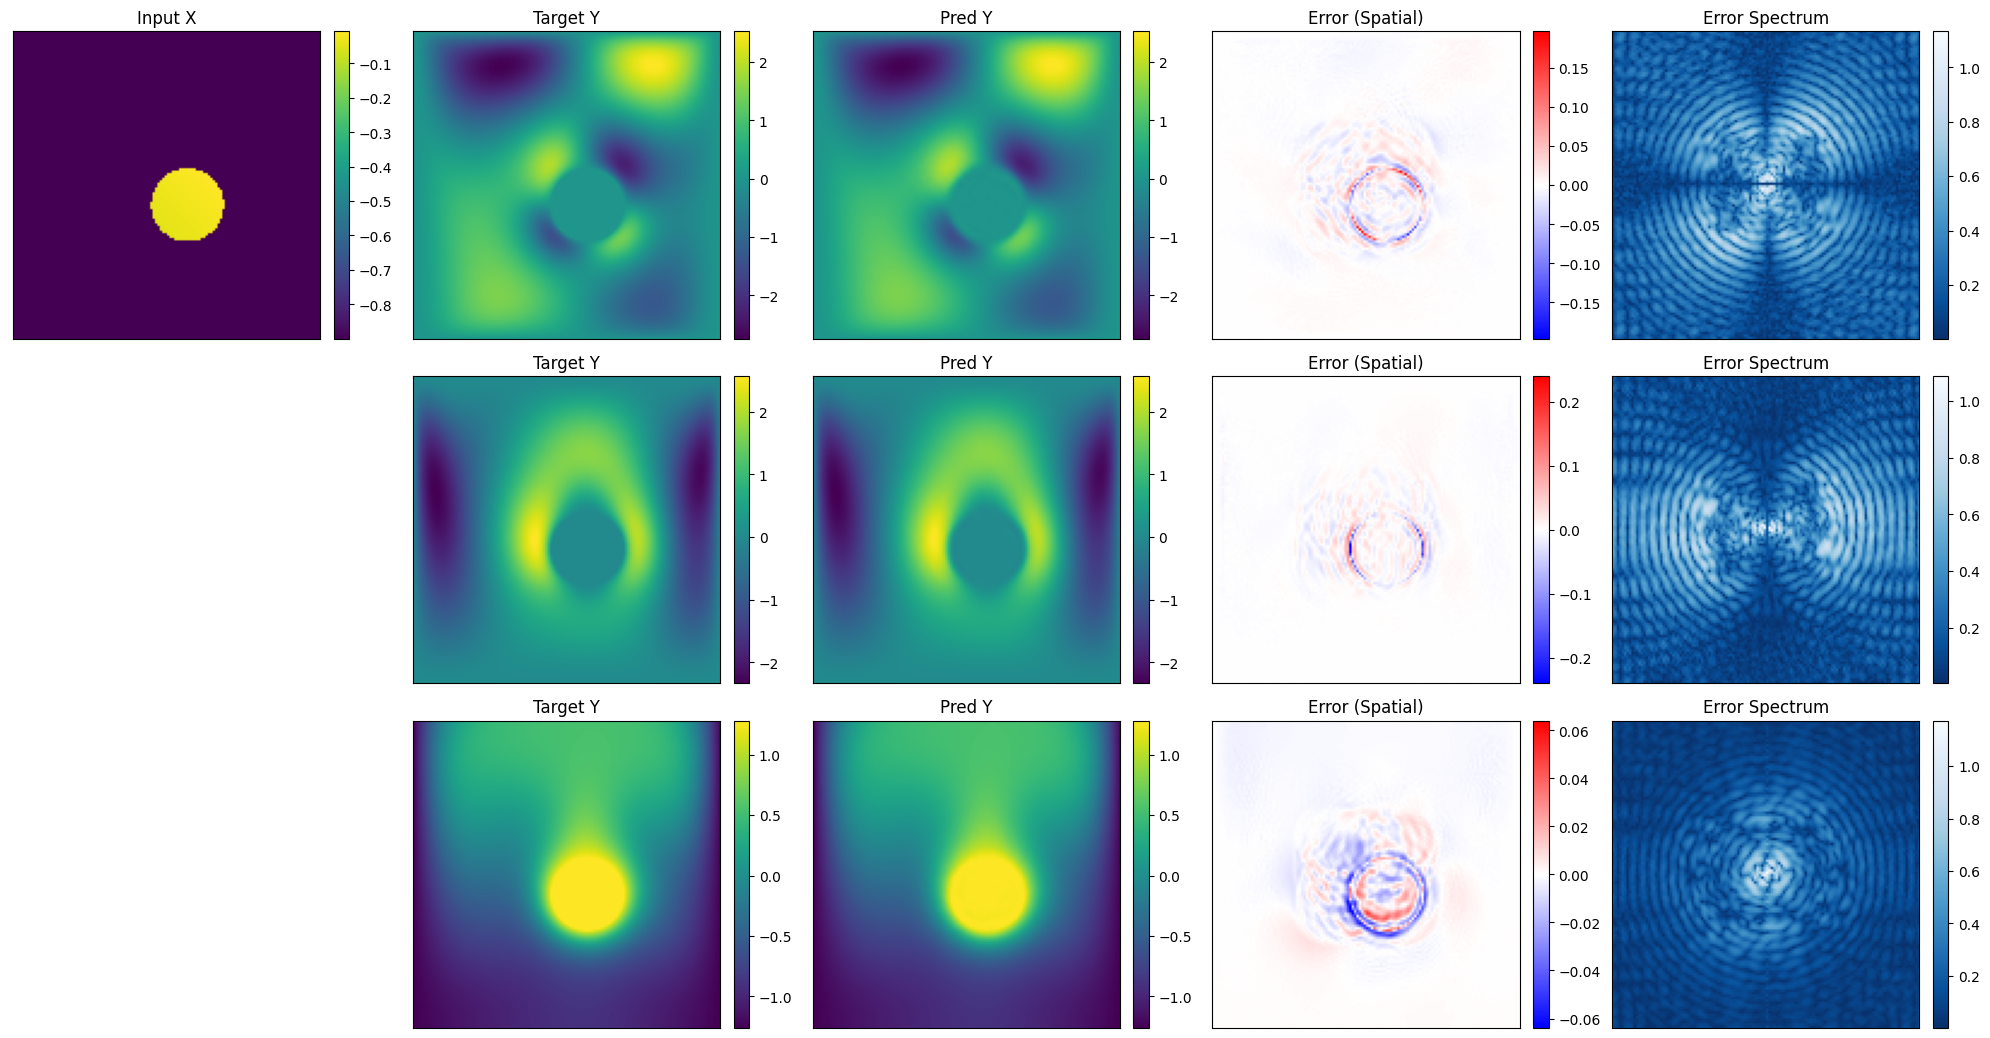

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=out_channels)

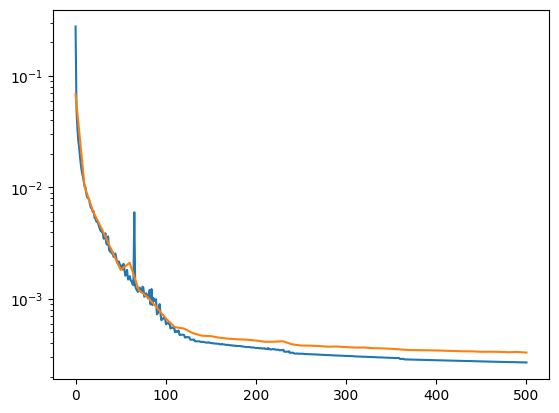

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## TE_Heat

In [ ]:
from utils import MPData
data_name = 'TE_heat'
model_name= 'CPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import ChannelPodONet
from neuralop.utils import count_model_params
p = 512
model = ChannelPodONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 11,476,672 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 11,476,672


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 2.50/0.10 | loss: 1.44e+00 | test: 1.38e+00 | norm: 0.08


epoch:10 | time: 2.53/0.10 | loss: 7.29e-01 | test: 9.60e-01 | norm: 0.25


epoch:20 | time: 2.51/0.10 | loss: 2.86e-01 | test: 3.10e-01 | norm: 0.18


epoch:30 | time: 2.51/0.10 | loss: 1.31e-01 | test: 1.27e-01 | norm: 0.11


epoch:40 | time: 2.52/0.10 | loss: 1.02e-01 | test: 9.53e-02 | norm: 0.14


...

epoch:470 | time: 2.50/0.10 | loss: 9.19e-04 | test: 8.64e-04 | norm: 0.00


epoch:480 | time: 2.52/0.10 | loss: 9.02e-04 | test: 8.50e-04 | norm: 0.00


epoch:490 | time: 2.52/0.10 | loss: 8.83e-04 | test: 8.34e-04 | norm: 0.00


epoch:499 | time: 2.51/0.10 | loss: 8.72e-04 | test: 8.23e-04 | norm: 0.00


Finish epoch:499 | train loss: 8.7180e-04 | test loss: 8.2321e-04
total train time : 1253.551
Channel Loss: var0: 3.6387e-04 var1: 3.6761e-04 var2: 9.1733e-05 



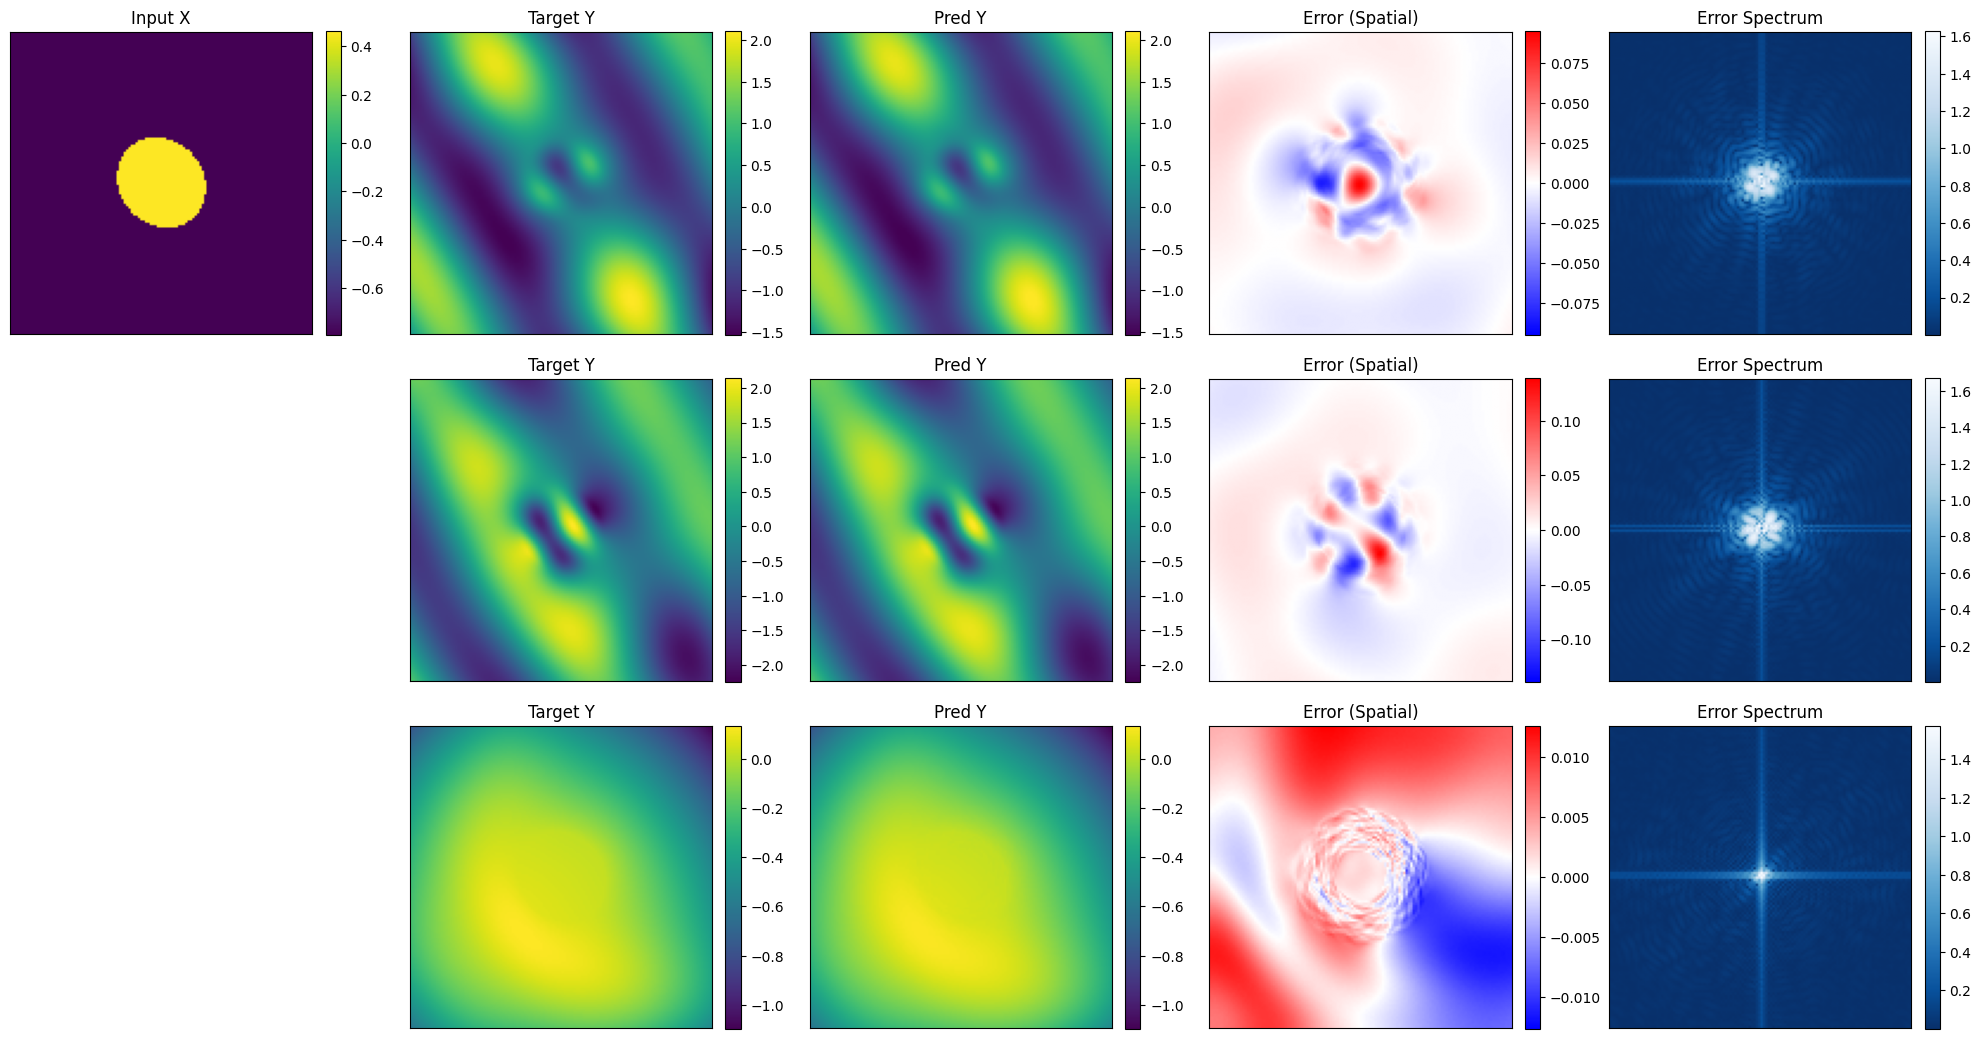

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

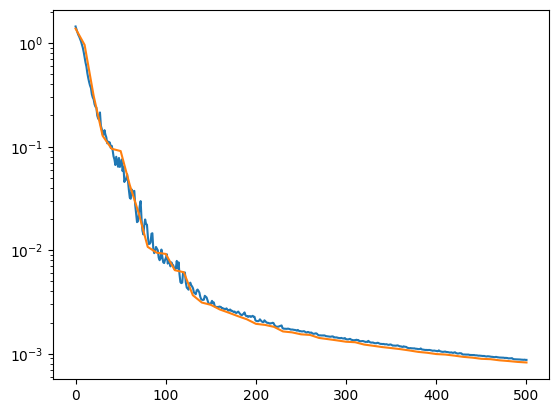

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## E_flow

In [ ]:
from utils import MPData
data_name = 'E_flow'
model_name= 'CPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import ChannelPodONet
from neuralop.utils import count_model_params
p = 4096
model = ChannelPodONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 22,497,472 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 22,497,472


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.85/0.13 | loss: 1.22e+00 | test: 6.90e-01 | norm: 0.45


epoch:10 | time: 3.89/0.13 | loss: 2.47e-01 | test: 2.26e-01 | norm: 0.88


epoch:20 | time: 3.83/0.13 | loss: 1.66e-01 | test: 1.61e-01 | norm: 0.40


epoch:30 | time: 3.87/0.13 | loss: 1.27e-01 | test: 1.25e-01 | norm: 0.27


epoch:40 | time: 3.84/0.15 | loss: 1.03e-01 | test: 1.00e-01 | norm: 0.15


...

epoch:470 | time: 3.88/0.13 | loss: 5.65e-02 | test: 5.61e-02 | norm: 0.00


epoch:480 | time: 3.85/0.13 | loss: 5.64e-02 | test: 5.60e-02 | norm: 0.00


epoch:490 | time: 3.91/0.13 | loss: 5.64e-02 | test: 5.60e-02 | norm: 0.00


epoch:499 | time: 3.89/0.13 | loss: 5.63e-02 | test: 5.60e-02 | norm: 0.00


Finish epoch:499 | train loss: 5.6345e-02 | test loss: 5.6003e-02
total train time : 1935.353
Channel Loss: var0: 3.2723e-04 var1: 2.4585e-02 var2: 3.1091e-02 



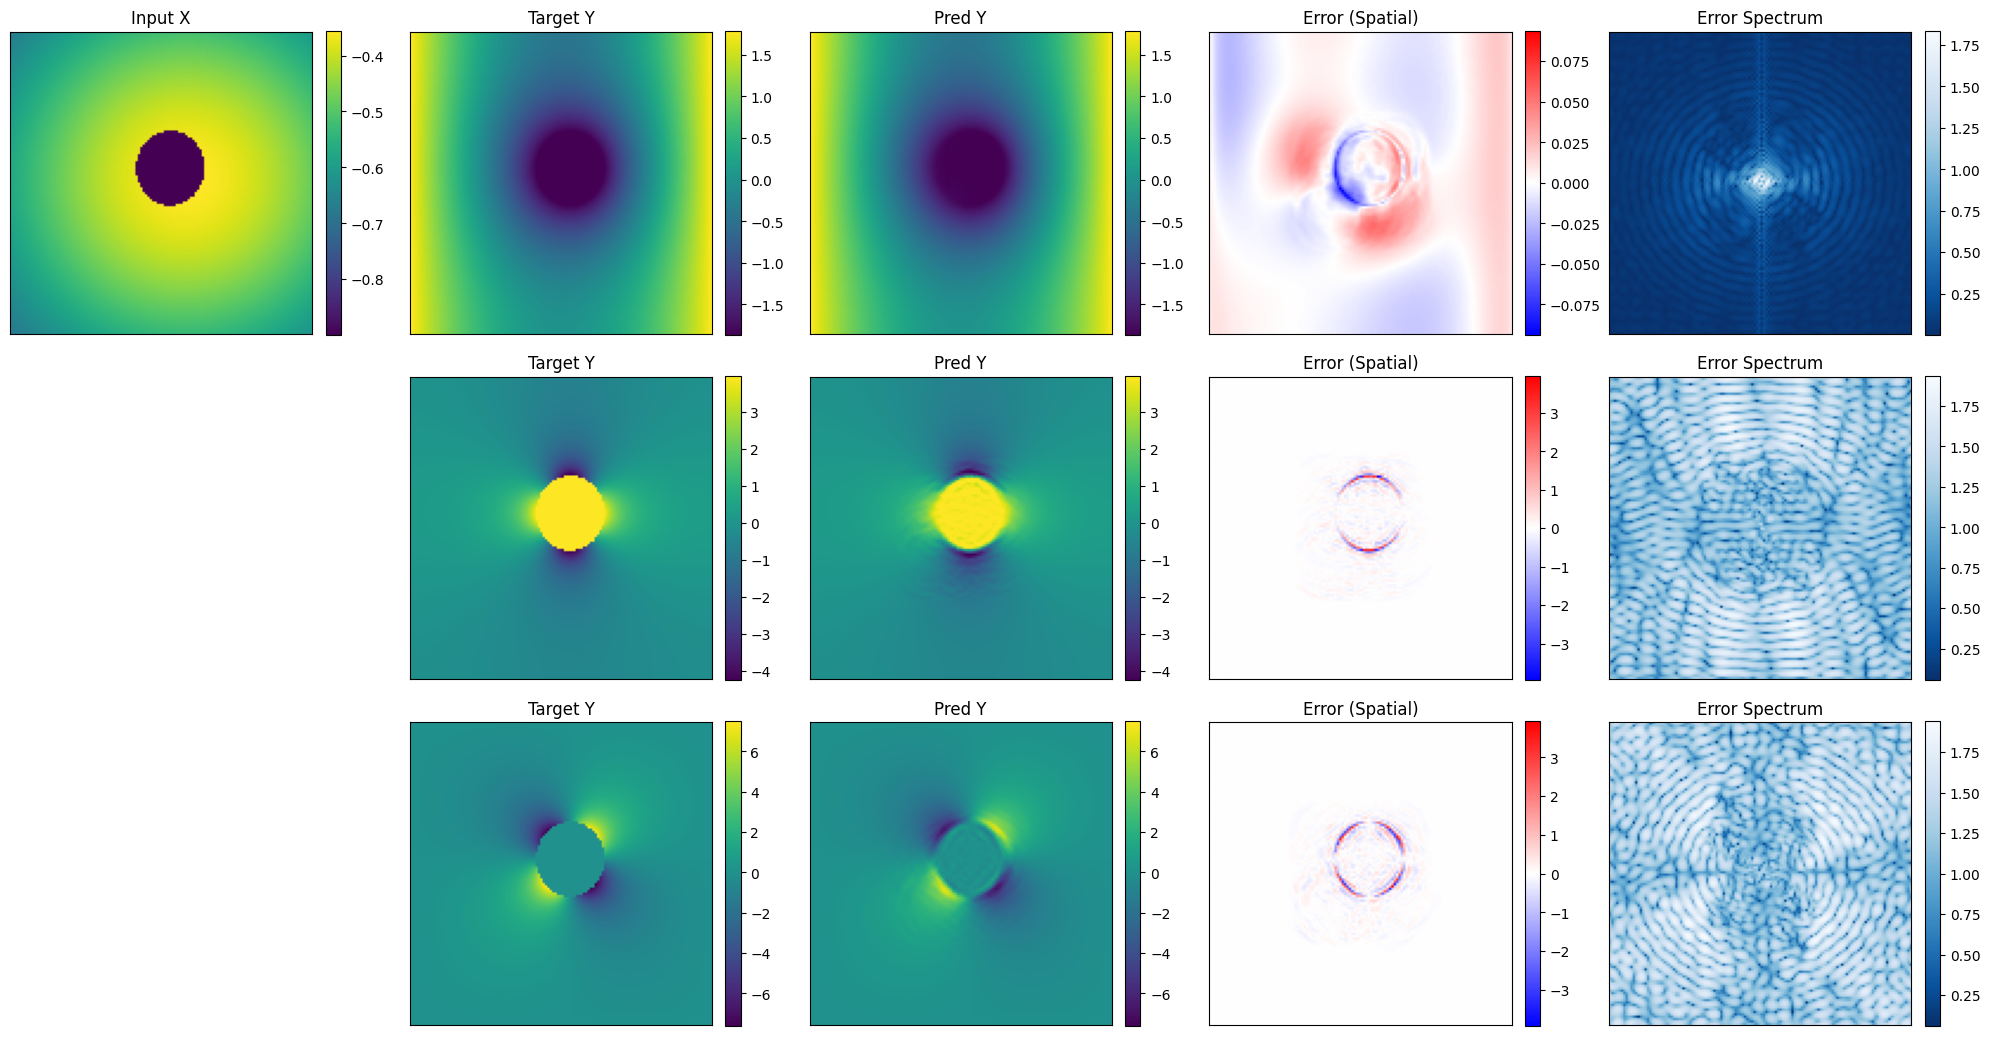

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

## MHD

In [ ]:
from utils import MPData
data_name = 'MHD'
model_name= 'CPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import ChannelPodONet
from neuralop.utils import count_model_params
p = 2048
model = ChannelPodONet(p=p, out_channels=5).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 20,398,272 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 20,398,272


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.84/0.14 | loss: 8.04e-01 | test: 1.78e-01 | norm: 0.17


epoch:10 | time: 3.84/0.14 | loss: 3.00e-02 | test: 4.37e-02 | norm: 0.04


epoch:20 | time: 3.84/0.15 | loss: 2.22e-02 | test: 4.40e-02 | norm: 0.03


epoch:30 | time: 3.84/0.14 | loss: 2.04e-02 | test: 3.06e-02 | norm: 0.02


epoch:40 | time: 3.84/0.14 | loss: 1.86e-02 | test: 2.61e-02 | norm: 0.01


...

epoch:470 | time: 3.83/0.14 | loss: 1.75e-02 | test: 2.52e-02 | norm: 0.01


epoch:480 | time: 3.83/0.14 | loss: 1.75e-02 | test: 2.52e-02 | norm: 0.01


epoch:490 | time: 3.84/0.15 | loss: 1.75e-02 | test: 2.52e-02 | norm: 0.01


epoch:499 | time: 3.84/0.14 | loss: 1.75e-02 | test: 2.52e-02 | norm: 0.01


Finish epoch:499 | train loss: 1.7487e-02 | test loss: 2.5151e-02
total train time : 1918.619
Channel Loss: var0: 2.6305e-04 var1: 1.9257e-04 var2: 2.4593e-02 var3: 2.4503e-05 var4: 7.7772e-05 



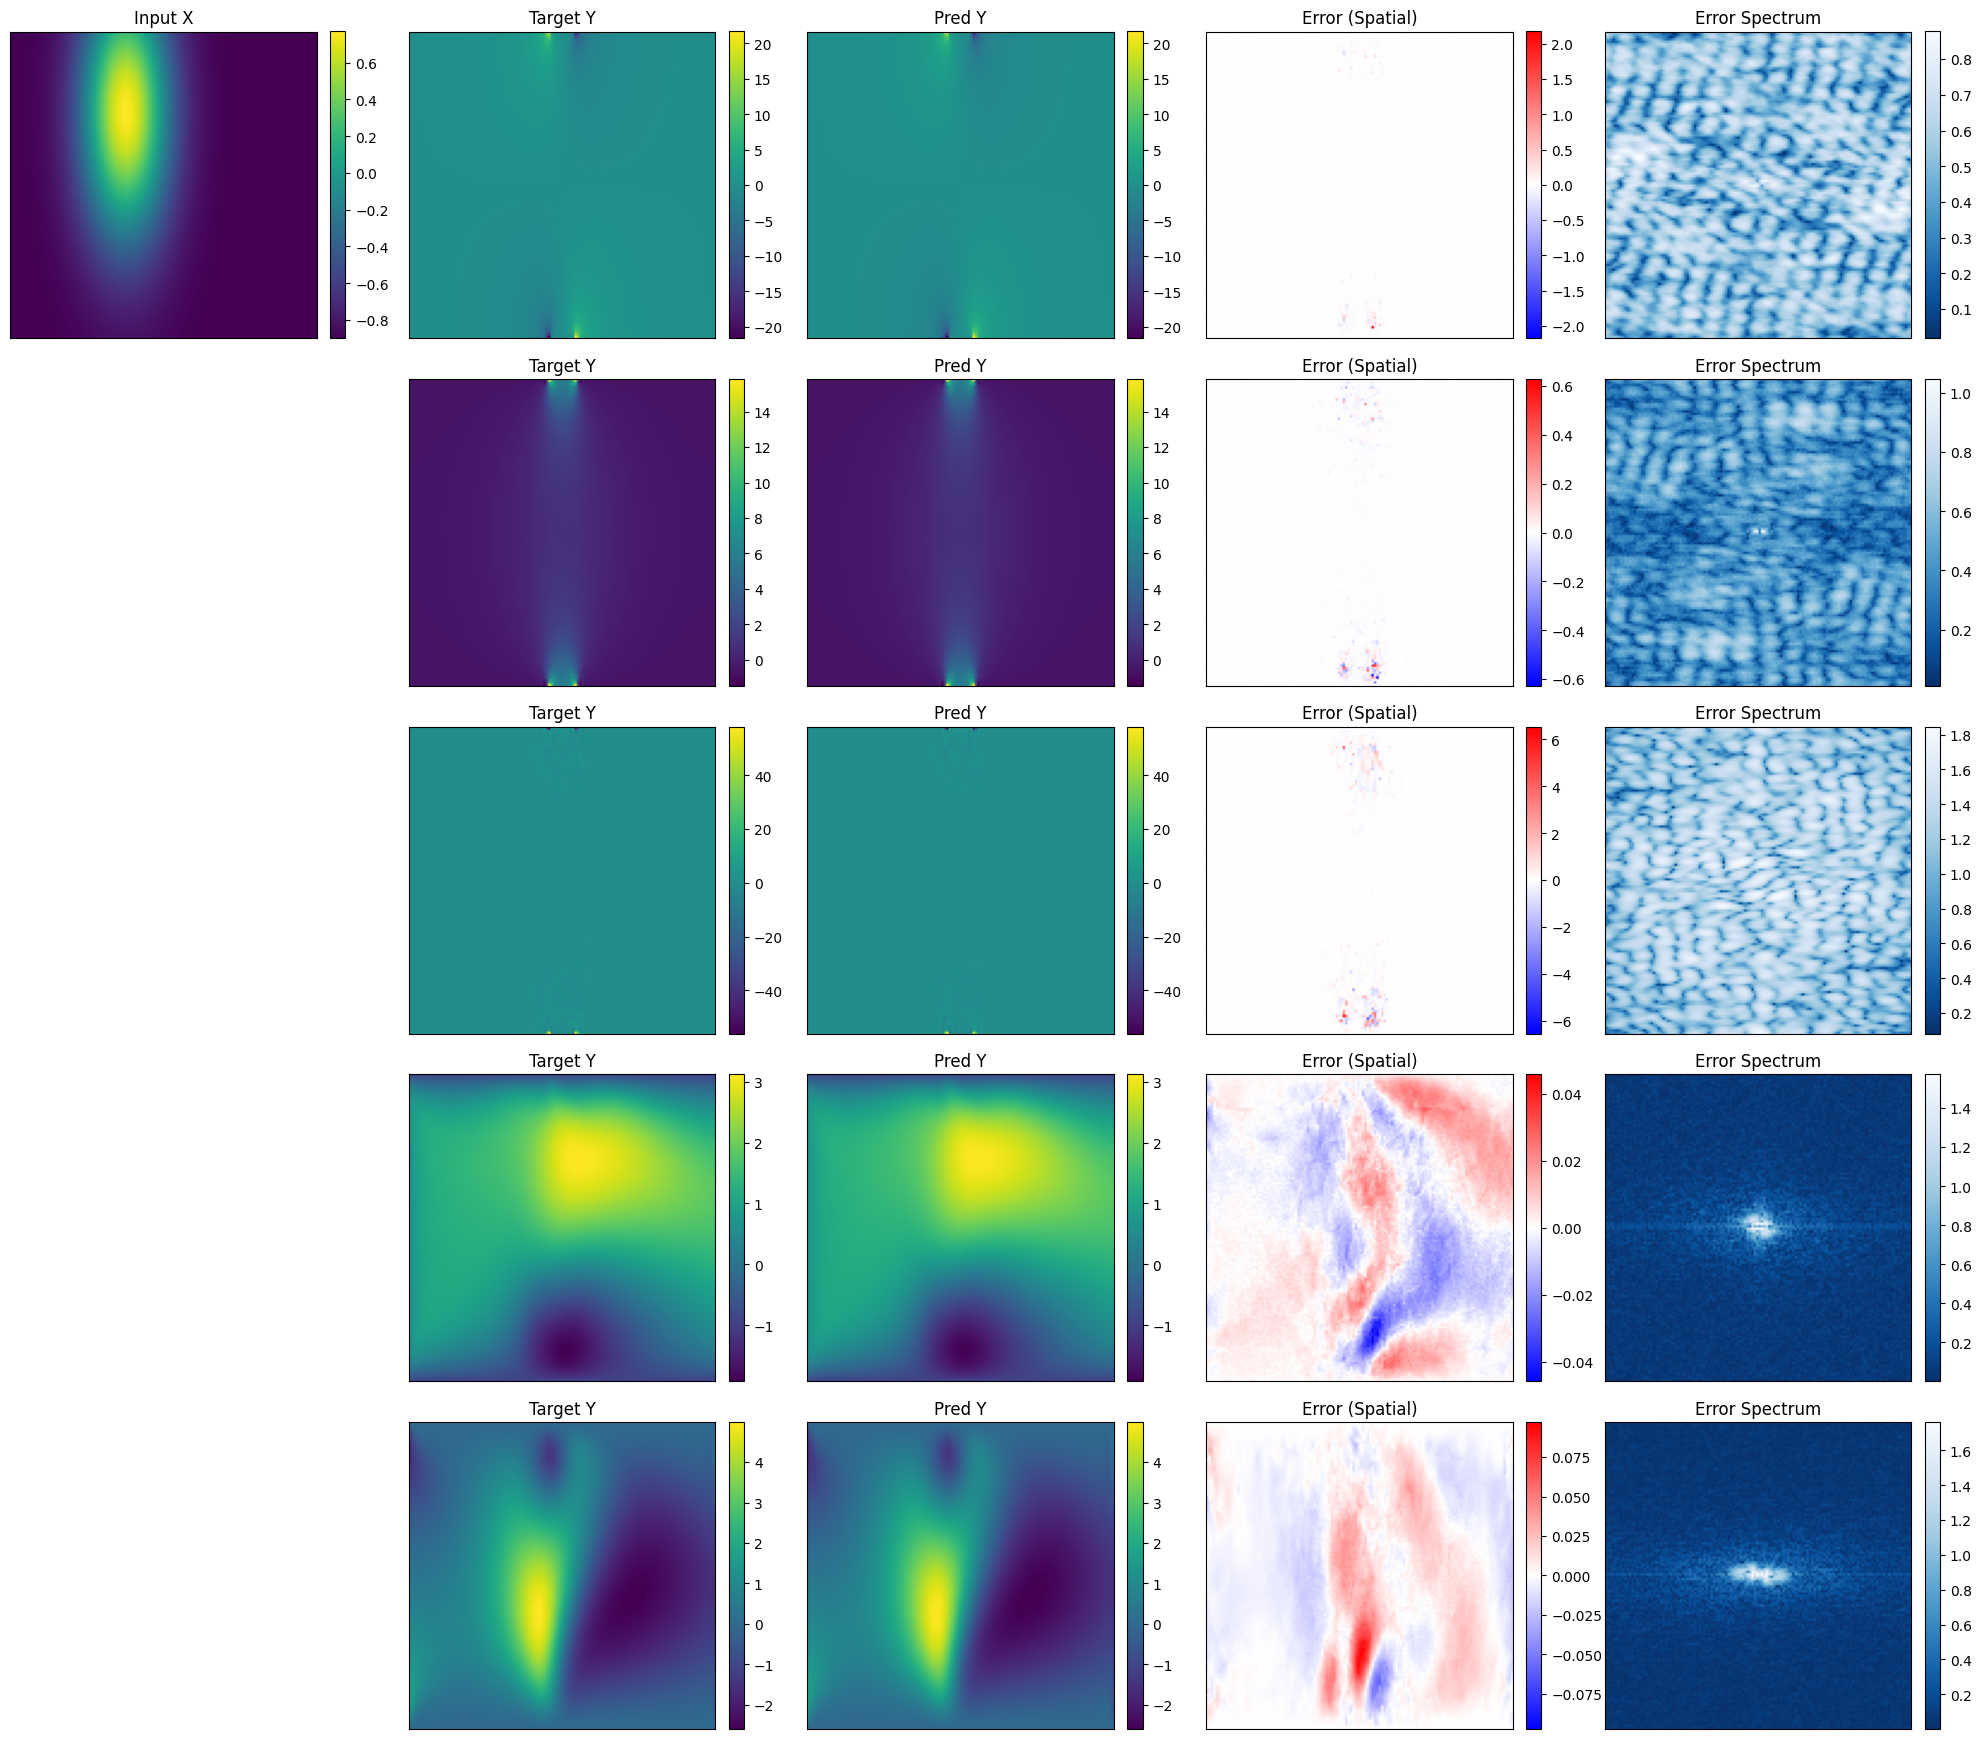

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=5)

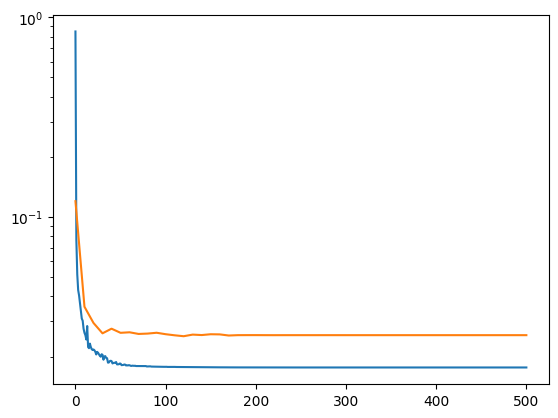

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')